In [1]:
import os
import pandas as pd
import json

In [5]:
# Base paths
base_csv_dir = r"C:/Users/Carol/Documents/Data Code and Deliverables/Data Group Part/Data/clinical-trial-outcome-prediction/Processed/hint"
base_json_dir = os.path.join(base_csv_dir, "text_description")

# Filter criteria
#valid_ccsr_values = ['NEO', 'DIG', 'INF']
valid_ccsr_values = ['NEO']

# Phases and splits
phases = ['phase_I', 'phase_II', 'phase_III']
splits = ['train', 'valid', 'test']

for phase in phases:
    for split in splits:
        # File names
        csv_filename = f"{phase}_{split}.csv"
        json_filename = f"{phase}_{split}.json"

        # Full paths
        csv_path = os.path.join(base_csv_dir, csv_filename)
        json_path = os.path.join(base_json_dir, json_filename)

        # Output file names
        filtered_csv_path = os.path.join(base_csv_dir, f"filtered_{csv_filename}")
        filtered_json_path = os.path.join(base_json_dir, f"filtered_{json_filename}")

        # Check if files exist
        if not os.path.exists(csv_path) or not os.path.exists(json_path):
            print(f"Skipping missing files: {csv_filename}, {json_filename}")
            continue

        # Load CSV and JSON
        df = pd.read_csv(csv_path)
        with open(json_path, 'r') as f:
            json_data = json.load(f)

        # Filter
        filtered_df = df[df['CCSR_MAIN'].isin(valid_ccsr_values)]
        filtered_indices = filtered_df.index.tolist()
        filtered_json_data = [json_data[i] for i in filtered_indices]

        # Save filtered CSV and JSON
        filtered_df.to_csv(filtered_csv_path, index=False)
        with open(filtered_json_path, 'w') as f:
            json.dump(filtered_json_data, f, indent=2)

        print(f"Saved: {filtered_csv_path}, {filtered_json_path}")


Saved: C:/Users/Carol/Documents/Data Code and Deliverables/Data Group Part/Data/clinical-trial-outcome-prediction/Processed/hint\filtered_phase_I_train.csv, C:/Users/Carol/Documents/Data Code and Deliverables/Data Group Part/Data/clinical-trial-outcome-prediction/Processed/hint\text_description\filtered_phase_I_train.json
Saved: C:/Users/Carol/Documents/Data Code and Deliverables/Data Group Part/Data/clinical-trial-outcome-prediction/Processed/hint\filtered_phase_I_valid.csv, C:/Users/Carol/Documents/Data Code and Deliverables/Data Group Part/Data/clinical-trial-outcome-prediction/Processed/hint\text_description\filtered_phase_I_valid.json
Saved: C:/Users/Carol/Documents/Data Code and Deliverables/Data Group Part/Data/clinical-trial-outcome-prediction/Processed/hint\filtered_phase_I_test.csv, C:/Users/Carol/Documents/Data Code and Deliverables/Data Group Part/Data/clinical-trial-outcome-prediction/Processed/hint\text_description\filtered_phase_I_test.json
Saved: C:/Users/Carol/Document

In [5]:
base_dir = r"C:/Users/Carol/Documents/Data Code and Deliverables/Data Group Part/Data/clinical-trial-outcome-prediction/Processed/hint"
phases = ['phase_I', 'phase_II', 'phase_III']

In [8]:
import os
import pandas as pd
for phase in phases:
    filename = f"{phase}_train.csv"  # ajusta se necessário (train/valid/test)
    filepath = os.path.join(base_dir, filename)

    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        continue

    # Carregar CSV
    df = pd.read_csv(filepath)

    # Verificar duplicados em "NCT Number"
    duplicates = df[df.duplicated(subset="NCT Number", keep=False)]
    print(f"[{phase.upper()}] Found {len(duplicates)} duplicated NCT Numbers.")


[PHASE_I] Found 0 duplicated NCT Numbers.
[PHASE_II] Found 0 duplicated NCT Numbers.
[PHASE_III] Found 0 duplicated NCT Numbers.


In [12]:
nan_count = df["fused_pred"].isna().sum()
print(f"[{phase.upper()}] Rows with missing Prediction: {nan_count}")


[PHASE_III] Rows with missing Prediction: 1633


In [15]:
if nan_count > 0:
    df_clean = df.dropna(subset=["fused_pred"])
else:
    df_clean = df.copy()
    
print(f"[{phase.upper()}] Final shape: {df_clean.shape}")


[PHASE_III] Final shape: (2532, 18)


In [16]:
if "CCSR_MAIN" not in df.columns or "label" not in df.columns:
    print("Erro: coluna 'CCSR_MAIN' ou 'label' não encontrada.")
else:
    # Contar quantos exemplos existem por CCSR_MAIN e label
    label_dist = df.groupby(["CCSR_MAIN", "label"]).size().unstack(fill_value=0)

    # Adicionar total por categoria
    label_dist["Total"] = label_dist.sum(axis=1)

    print("\nDistribuição do label por CCSR_MAIN:\n")
    print(label_dist.sort_values("Total", ascending=False))


Distribuição do label por CCSR_MAIN:

label       0    1  Total
CCSR_MAIN                
UNKNOWN    98  715    813
INF        73  521    594
END        58  383    441
NEO        71  329    400
MBD        37  265    302
DIG        34  194    228
CIR        32  192    224
BLD        24  178    202
NVS        29  144    173
GEN        22  128    150
MUS        13  131    144
EYE        13  105    118
SKN        12   81     93
SYM         6   67     73
RSP         8   50     58
PRG        10   46     56
INJ         9   19     28
MAL         3   23     26
PNL         7   11     18
EXT         2   12     14
EAR         3    7     10


In [17]:
import pandas as pd
import os

# Diretório onde estão os CSVs
base_dir = "C:/Users/Carol/Documents/Data Code and Deliverables/Data Group Part/Data/clinical-trial-outcome-prediction/Processed/hint"
phases = ['phase_I', 'phase_II', 'phase_III']
split = 'train'  # ou 'valid', 'test'

# Lista para guardar os DataFrames de cada fase
df_list = []

for phase in phases:
    csv_path = os.path.join(base_dir, f"{phase}_{split}.csv")
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        df["phase"] = phase  # opcional, se quiseres rastrear de qual fase veio
        df_list.append(df)
    else:
        print(f"Ficheiro não encontrado: {csv_path}")

# Concatenar tudo num único DataFrame
df_all = pd.concat(df_list, ignore_index=True)

# Verificar se as colunas necessárias existem
if "CCSR_MAIN" not in df_all.columns or "label" not in df_all.columns:
    print("Colunas 'CCSR_MAIN' ou 'label' não encontradas.")
else:
    # Distribuição por CCSR_MAIN e label
    dist = df_all.groupby(["CCSR_MAIN", "label"]).size().unstack(fill_value=0)
    dist["Total"] = dist.sum(axis=1)

    print("\nDistribuição do label por CCSR_MAIN (todas as fases):\n")
    print(dist.sort_values("Total", ascending=False))



Distribuição do label por CCSR_MAIN (todas as fases):

label        0     1  Total
CCSR_MAIN                  
UNKNOWN    645  3727   4372
NEO        588  2065   2653
INF        260  1514   1774
END        182  1070   1252
DIG        149   789    938
MBD        117   759    876
NVS        148   598    746
BLD        116   533    649
CIR         97   447    544
GEN         78   379    457
MUS         47   304    351
EYE         47   298    345
SKN         52   289    341
SYM         37   226    263
PRG         46   190    236
RSP         24   129    153
EXT         10    95    105
MAL         17    84    101
INJ         25    68     93
PNL         17    54     71
EAR          7    16     23


In [19]:
import pandas as pd
import os

# Diretório onde estão os CSVs
base_dir = "C:/Users/Carol/Documents/Data Code and Deliverables/Data Group Part/Data/clinical-trial-outcome-prediction/Processed/hint"
phases = ['phase_I', 'phase_II', 'phase_III']
split = 'valid'  # ou 'valid', 'test'

# Lista para guardar os DataFrames de cada fase
df_list = []

for phase in phases:
    csv_path = os.path.join(base_dir, f"{phase}_{split}.csv")
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        df["phase"] = phase  # opcional, se quiseres rastrear de qual fase veio
        df_list.append(df)
    else:
        print(f"Ficheiro não encontrado: {csv_path}")

# Concatenar tudo num único DataFrame
df_all = pd.concat(df_list, ignore_index=True)

# Verificar se as colunas necessárias existem
if "CCSR_MAIN" not in df_all.columns or "label" not in df_all.columns:
    print("Colunas 'CCSR_MAIN' ou 'label' não encontradas.")
else:
    # Distribuição por CCSR_MAIN e label
    dist = df_all.groupby(["CCSR_MAIN", "label"]).size().unstack(fill_value=0)
    dist["Total"] = dist.sum(axis=1)

    print("\nDistribuição do label por CCSR_MAIN (todas as fases):\n")
    print(dist.sort_values("Total", ascending=False))



Distribuição do label por CCSR_MAIN (todas as fases):

label        0    1  Total
CCSR_MAIN                 
UNKNOWN    161  763    924
NEO        223  341    564
INF         61  304    365
END         48  200    248
DIG         48  172    220
MBD         25  141    166
NVS         45  115    160
BLD         38  121    159
SKN         23   90    113
CIR         21   83    104
GEN         26   60     86
MUS         13   68     81
EYE         20   55     75
PRG          7   48     55
SYM          7   37     44
RSP          8   30     38
INJ          7   26     33
EXT          1   24     25
MAL          9   14     23
PNL          4   12     16
EAR          1    5      6


In [20]:
import pandas as pd
import os

# Diretório onde estão os CSVs
base_dir = "C:/Users/Carol/Documents/Data Code and Deliverables/Data Group Part/Data/clinical-trial-outcome-prediction/Processed/hint"
phases = ['phase_I', 'phase_II', 'phase_III']
split = 'test'  # ou 'valid', 'test'

# Lista para guardar os DataFrames de cada fase
df_list = []

for phase in phases:
    csv_path = os.path.join(base_dir, f"{phase}_{split}.csv")
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        df["phase"] = phase  # opcional, se quiseres rastrear de qual fase veio
        df_list.append(df)
    else:
        print(f"Ficheiro não encontrado: {csv_path}")

# Concatenar tudo num único DataFrame
df_all = pd.concat(df_list, ignore_index=True)

# Verificar se as colunas necessárias existem
if "CCSR_MAIN" not in df_all.columns or "label" not in df_all.columns:
    print("Colunas 'CCSR_MAIN' ou 'label' não encontradas.")
else:
    # Distribuição por CCSR_MAIN e label
    dist = df_all.groupby(["CCSR_MAIN", "label"]).size().unstack(fill_value=0)
    dist["Total"] = dist.sum(axis=1)

    print("\nDistribuição do label por CCSR_MAIN (todas as fases):\n")
    print(dist.sort_values("Total", ascending=False))



Distribuição do label por CCSR_MAIN (todas as fases):

label        0    1  Total
CCSR_MAIN                 
UNKNOWN    267  787   1054
NEO        224  225    449
INF        107  265    372
DIG         93  167    260
END         56  181    237
BLD         46  109    155
MBD         50   99    149
NVS         51   86    137
CIR         35   63     98
EYE         14   79     93
MUS         26   64     90
SKN         24   64     88
GEN         19   47     66
RSP         15   35     50
PRG         29   20     49
SYM         11   31     42
INJ         12   26     38
EXT          2   28     30
MAL         11   10     21
PNL          7   12     19
EAR          2    3      5


In [24]:
import os
import pandas as pd

# Diretório base
base_csv_dir = r"C:/Users/Carol/Documents/Data Code and Deliverables/Data Group Part/Data/clinical-trial-outcome-prediction/Processed/hint"

# Filtro aplicado
valid_ccsr_values = ['NEO']

# Fases e splits
phases = ['phase_I', 'phase_II', 'phase_III']
splits = ['train', 'valid', 'test']

for phase in phases:
    for split in splits:
        # Nome do ficheiro original
        csv_filename = f"{phase}_{split}.csv"
        csv_path = os.path.join(base_csv_dir, csv_filename)

        # Nome do ficheiro de saída
        filtered_csv_filename = f"filtered_{csv_filename}"
        filtered_csv_path = os.path.join(base_csv_dir, filtered_csv_filename)

        # Verificar se o ficheiro existe
        if not os.path.exists(csv_path):
            print(f"[{phase.upper()} - {split}] File not found: {csv_path}")
            continue

        # Carregar dados
        df = pd.read_csv(csv_path)

        # Verificar colunas necessárias
        required_cols = ['CCSR_MAIN', 'NCT Number', 'fused_pred']
        if not all(col in df.columns for col in required_cols):
            print(f"[{phase.upper()} - {split}] Missing required columns.")
            continue

        # Filtrar por CCSR_MAIN = 'NEO'
        df = df[df['CCSR_MAIN'].isin(valid_ccsr_values)]

        # Remover duplicados por NCT Number (mantém o primeiro)
        before_dedup = df.shape[0]
        df = df.drop_duplicates(subset='NCT Number', keep='first')
        after_dedup = df.shape[0]

        # Remover linhas com NaN em fused_pred
        before_nan = df.shape[0]
        df = df.dropna(subset=['fused_pred'])
        after_nan = df.shape[0]

        # Salvar CSV final
        df.to_csv(filtered_csv_path, index=False)

        print(
            f"[{phase.upper()} - {split}] Saved: {filtered_csv_path} | "
            f"Rows kept: {after_nan} | "
            f"Removed {before_dedup - after_dedup} duplicates, {before_nan - after_nan} NaNs"
        )


[PHASE_I - train] Saved: C:/Users/Carol/Documents/Data Code and Deliverables/Data Group Part/Data/clinical-trial-outcome-prediction/Processed/hint\filtered_phase_I_train.csv | Rows kept: 697 | Removed 0 duplicates, 205 NaNs
[PHASE_I - valid] Saved: C:/Users/Carol/Documents/Data Code and Deliverables/Data Group Part/Data/clinical-trial-outcome-prediction/Processed/hint\filtered_phase_I_valid.csv | Rows kept: 148 | Removed 0 duplicates, 30 NaNs
[PHASE_I - test] Saved: C:/Users/Carol/Documents/Data Code and Deliverables/Data Group Part/Data/clinical-trial-outcome-prediction/Processed/hint\filtered_phase_I_test.csv | Rows kept: 110 | Removed 0 duplicates, 28 NaNs
[PHASE_II - train] Saved: C:/Users/Carol/Documents/Data Code and Deliverables/Data Group Part/Data/clinical-trial-outcome-prediction/Processed/hint\filtered_phase_II_train.csv | Rows kept: 900 | Removed 0 duplicates, 451 NaNs
[PHASE_II - valid] Saved: C:/Users/Carol/Documents/Data Code and Deliverables/Data Group Part/Data/clinica

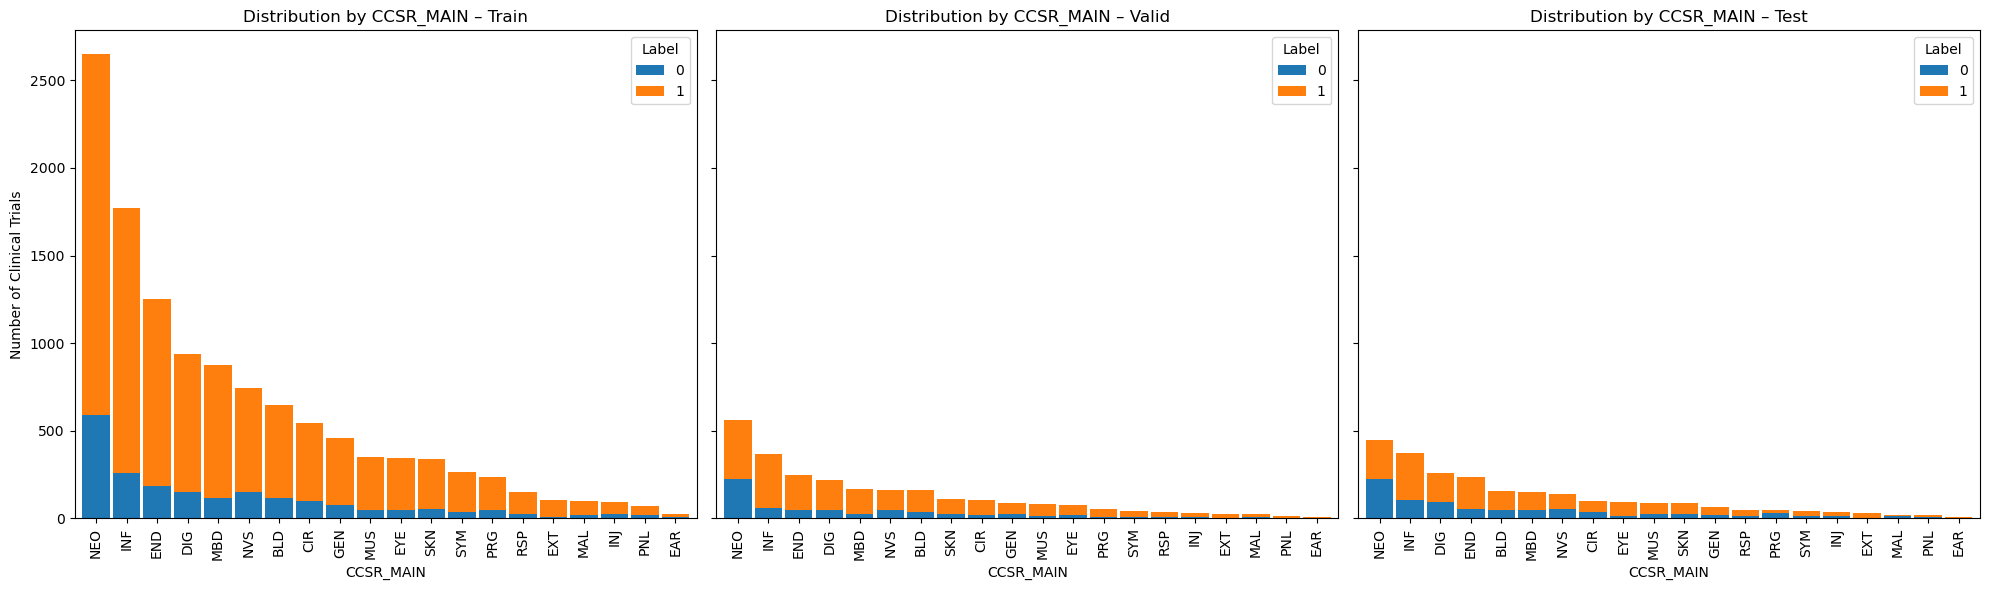

In [25]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# Caminho base onde estão os CSVs
base_csv_dir = r"C:/Users/Carol/Documents/Data Code and Deliverables/Data Group Part/Data/clinical-trial-outcome-prediction/Processed/hint"

# Fases e splits
phases = ['phase_I', 'phase_II', 'phase_III']
splits = ['train', 'valid', 'test']

# Guardar distribuições por split
all_distributions = {}

for split in splits:
    df_list = []
    for phase in phases:
        file_path = os.path.join(base_csv_dir, f"{phase}_{split}.csv")
        if os.path.exists(file_path):
            df = pd.read_csv(file_path)
            df["phase"] = phase  # opcional
            df_list.append(df)
        else:
            print(f"Arquivo não encontrado: {file_path}")
    
    if df_list:
        combined_df = pd.concat(df_list, ignore_index=True)

        # Remover linhas com CCSR_MAIN == 'UNKNOWN'
        combined_df = combined_df[combined_df["CCSR_MAIN"] != "UNKNOWN"]
        
        if "CCSR_MAIN" in combined_df.columns and "label" in combined_df.columns:
            dist = combined_df.groupby(["CCSR_MAIN", "label"]).size().unstack(fill_value=0)
            dist["Total"] = dist.sum(axis=1)
            all_distributions[split] = dist.sort_values("Total", ascending=False)

# Plotar gráficos
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for idx, split in enumerate(splits):
    if split in all_distributions:
        dist = all_distributions[split]
        dist[[0, 1]].plot(kind='bar', stacked=True, ax=axs[idx], width=0.9)
        axs[idx].set_title(f"Distribution by CCSR_MAIN – {split.capitalize()}")
        axs[idx].set_xlabel("CCSR_MAIN")
        axs[idx].set_ylabel("Number of Clinical Trials")
        axs[idx].legend(title="Label")
        axs[idx].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()
